# Import

In [1]:
import os
import gc
import random
from tqdm import tqdm, trange

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from scipy import signal

import torch
import matplotlib.pyplot as plt
from torch import tensor
from torch.optim import Adam
from torch.utils.data import random_split, DataLoader
from torch.nn.functional import normalize
# from torch.utils.data import Dataset, TensorDataset

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

import shap

# Config

In [2]:
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
INTENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
EXPERIMETS = datasets = ["Mona Lisa", "Necker cube"]
RHYTHMS = signal_fiq= ['delta','theta','alpha','beta','gamma']
DATA_DIR = 'Datasets/'
CP_DIR = 'Checkpoints/'
DATASET = []

torch.cuda.empty_cache()
gc.collect()

from torch import nn

class Config:
    batch_size = 64
    threshold = 0.001
    seed = 42
    n_folds = 20
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    epochs = 200
    in_features = 15000
    out_features  = 2500
    activation=nn.ReLU()
    loss_func = nn.CrossEntropyLoss()
    es_patience = 20
    lr_patience = 5
    lr = 0.01

print(Config.device)

def set_seed(seed = 42):
    """Utility function to set seed across all pytorch process for repeatable experiment
    """
    torch.initial_seed() % 2**32
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)
    gseed = torch.Generator().manual_seed(seed)
    # print(worker_seed)
    return gseed

set_seed(Config.seed)

cuda


# Robiul preparation

In [3]:
class EEG:
    def __init__(self, participant,datasets):

        self.int = {}
        self.delta = {}
        self.theta = {}
        self.alpha = {}
        self.beta = {}
        self.gamma = {}

        for dataset in datasets:
            if dataset == "Mona Lisa":
                Dname = "/Figs for spectra"
                var1 = "/Backgr_int_"
                var2 = ".dat"
            else:
                Dname = "/Cubes for spectra"
                var1 = "/Backgr_int_"
                var2 = "_type_0.4.dat"

        for intensity in INTENSITIES:
            S = os.path.join(base, "Participant " + str(participant) + Dname + var1 + str(intensity) + var2)
            I = intensity
            self.int[I] = np.loadtxt(S)
            delta_signal = np.empty(self.int[I].shape)
            theta_signal =  np.empty(self.int[I].shape)
            alpha_signal = np.empty(self.int[I].shape)
            beta_signal = np.empty(self.int[I].shape)
            gamma_signal = np.empty(self.int[I].shape)

            for c in range(self.int[I].shape[1]):
                delta_signal[:,c], theta_signal[:,c],alpha_signal[:, c], beta_signal[:, c],gamma_signal[:,c] = self.fir_filtering(I, c)
            self.delta[I] = delta_signal
            self.theta[I] = theta_signal
            self.alpha[I] = alpha_signal
            self.beta[I] = beta_signal 
            self.gamma[I] = gamma_signal

    def fir_filtering(self, I, c):
        filter_delta = signal.firwin(400, [1.0, 4.0], pass_zero=False, fs=250)
        filter_theta = signal.firwin(400, [5.0, 8.0], pass_zero=False, fs=250)
        filter_alpha = signal.firwin(400, [8.0, 12.0], pass_zero=False, fs=250)
        filter_beta = signal.firwin(400, [13.0, 30.0], pass_zero=False, fs=250)
        filter_gamma = signal.firwin(400, [31.0, 45.0], pass_zero=False, fs=250)
        res_delta = signal.convolve(self.int[I][:, c], filter_delta, mode='same')
        res_theta = signal.convolve(self.int[I][:, c], filter_theta, mode='same')
        res_alpha = signal.convolve(self.int[I][:, c], filter_alpha, mode='same')
        res_beta = signal.convolve(self.int[I][:, c], filter_beta, mode='same')
        res_gamma = signal.convolve(self.int[I][:, c], filter_gamma, mode='same')
        
        return res_delta,res_theta, res_alpha,res_beta,res_gamma 

In [6]:
Intencity = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
file_path = os.path.join(base, "Channels.dat")
df_channels = pd.read_csv(file_path, header=None, sep='.')
channel_names = df_channels.iloc[:, -1:].values.flatten()

def convart_sin_fiq(fiq):
  if fiq == 'delta':
    return 1
  elif fiq == 'theta':
    return 2
  elif fiq == 'alpha':
    return 3
  elif fiq =='beta': 
    return 4
  elif fiq == 'gamma':
    return 5

def createdataframe(user,dataset,signal_fiq):
    global Intencity,channel_names
    tem_signal = []
    eeg_person = EEG(user,dataset)
    for i in Intencity:
        for ch in range(0,31):
            tem = [dataset,ch,channel_names[ch],convart_sin_fiq(signal_fiq),signal_fiq,i,user]
            # tem = [channel_names[ch]]
            S = 'tem_signal.append(np.append(tem, eeg_person.'+signal_fiq+'.get(i)[:,ch][0:15000]))'
            eval(S)
    
           
    tem_dataframe = pd.DataFrame(tem_signal)

    colunm = [] 

    colunm.append("Dataset")
    colunm.append("channel")
    colunm.append("Channel_Name")
    colunm.append("band")
    colunm.append("frequency")
    colunm.append("Intencity")
    colunm.append("participant")

    for col in range(0,15000):
      S = 'Time'+str(col)
      colunm.append(S)    
    
    
    
    tem_dataframe.columns  = colunm 
    return tem_dataframe

# Dataset

In [7]:
df = DataFrame()

for experiment in EXPERIMETS:
    for rhythm in RHYTHMS:
        participants = trange(1, 11, leave=True)
        for user in participants:
            df = pd.concat([df, createdataframe(user, experiment, rhythm)], ignore_index=True)
            participants.set_postfix(rhythm=rhythm, user=user, counts=len(df),  experiment=experiment, refresh=True)

100%|█| 10/10 [00:33<00:00,  3.37s/it, counts=3100, experiment=Mona Lisa, rhythm
100%|█| 10/10 [00:41<00:00,  4.11s/it, counts=6200, experiment=Mona Lisa, rhythm
100%|█| 10/10 [00:49<00:00,  4.99s/it, counts=9300, experiment=Mona Lisa, rhythm
100%|█| 10/10 [00:58<00:00,  5.86s/it, counts=12400, experiment=Mona Lisa, rhyth
100%|█| 10/10 [01:07<00:00,  6.73s/it, counts=15500, experiment=Mona Lisa, rhyth
100%|█| 10/10 [01:16<00:00,  7.61s/it, counts=18600, experiment=Necker cube, rhy
100%|█| 10/10 [01:26<00:00,  8.69s/it, counts=21700, experiment=Necker cube, rhy
100%|█| 10/10 [01:34<00:00,  9.47s/it, counts=24800, experiment=Necker cube, rhy
100%|█| 10/10 [01:52<00:00, 11.20s/it, counts=27900, experiment=Necker cube, rhy
100%|█| 10/10 [01:55<00:00, 11.53s/it, counts=31000, experiment=Necker cube, rhy


In [8]:
df

,Dataset,channel,Channel_Name,band,frequency,Intencity,participant,Time0,Time1,Time2,...,Time14990,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999
0,Mona Lisa,0,O2-A2,1,delta,0.1,1,7.772970544879844,30.677260160175926,53.41413103932174,...,23.44867986640574,22.885068815607795,22.34066999595244,21.82352034357666,21.333030537649503,20.86100440490908,20.41249461889208,19.997011777502465,19.6112798564008,19.253296357169667
1,Mona Lisa,1,O1-A1,1,delta,0.1,1,3.5522059078923567,6.295904135536704,9.036222397464512,...,21.018630864669976,19.588754952288987,18.119286213923715,16.61815966164349,15.088949880952768,13.542232213787255,11.998175358860179,10.470979635699344,8.958667902212145,7.460397960314374
2,Mona Lisa,2,P4-A2,1,delta,0.1,1,15.108176599269667,25.54891796871998,35.96358649636977,...,-4.701106938237066,-4.679370408629602,-4.529878757525804,-4.25758485064557,-3.867217313307317,-3.3644148923882247,-2.7542051780022607,-2.040050773983246,-1.2267393965792945,-0.3193421504075806
3,Mona Lisa,3,P3-A1,1,delta,0.1,1,29.873366329465867,38.39422888844447,46.917213057741165,...,-0.13862982204966812,-0.3621678784078668,-0.4997429014105872,-0.548831119445365,-0.5132411735242943,-0.38905979926704237,-0.16728967693891628,0.1513494520793921,0.5580716770116986,1.0519768799376996
4,Mona Lisa,4,C4-A2,1,delta,0.1,1,8.9500413838161,12.746145708344514,16.674943619058503,...,23.339470418854965,23.928307291732757,24.552676931875244,25.20547623191569,25.884569191047152,26.589298350887965,27.31903654537524,28.07596027012317,28.86312436087364,29.68184437745307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30995,Necker cube,26,TP7-A1,5,gamma,1,10,-5.063616615173263,-34.848162231380385,-35.540869956162055,...,-6.1234053953610506,-4.67559780313541,-0.0053996391601351945,4.520409485071966,5.907745948519985,3.494135384933834,-0.9270291995263236,-4.533665836555034,-5.23680443606683,-2.7244778655558726
30996,Necker cube,27,CP3-A1,5,gamma,1,10,-1.0834646952318967,-25.976343042195616,-28.99538880952301,...,-2.8214792875896606,-1.6201397744136017,0.7019013649275934,2.5587911050054544,2.7769340758969854,1.311421125200873,-0.8718641019992894,-2.4834741052950022,-2.6231124084222586,-1.177813314325423
30997,Necker cube,28,Cpz-A1,5,gamma,1,10,0.5280047173021577,-29.790202652843483,-35.16004830227177,...,0.3820997696187973,3.0476986712590346,3.607091458598738,1.6272149886077152,-1.40262618858727,-3.2091043750323394,-2.5343470112402215,-0.08684113008274963,2.148047366545981,2.592469341625449
30998,Necker cube,29,CP4-A2,5,gamma,1,10,5.119117898147533,52.95349849703166,56.0140688817377,...,4.370696415860277,5.478094841063207,2.4528397430338877,-2.763486976544712,-6.255422043788858,-5.162900866436608,-0.13233350686724776,4.991012220818803,6.186158324049497,2.5614998508523996


In [9]:
dataset = DatasetDict()
splits = df['frequency'].unique()

for split in tqdm(splits):
    # dataset = DatasetDict(
    #     {split: Dataset.from_pandas(df[df['frequency'] == split])}
    # )
    dataset[split] = Dataset.from_pandas(df[df['frequency'] == split], split=split)

print(dataset)

100%|████████████████████████████████████████████| 5/5 [12:03<00:00, 144.65s/it]

DatasetDict({
    delta: Dataset({
        features: ['Dataset', 'channel', 'Channel_Name', 'band', 'frequency', 'Intencity', 'participant', 'Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86',

In [10]:
dataset.save_to_disk('test')

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

In [11]:
# df.to_csv('dataframe.csv')
# df = pd.read_csv('dataframe.csv', index_col=0)

In [12]:
# dataset = Dataset.from_pandas(df)
dataset.save_to_disk(DATA_DIR)

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

## Loading

In [13]:
dataset = load_from_disk(DATA_DIR)

In [14]:
df = dataset['beta'].to_pandas()
tdf = df.iloc[:, 7:]
tdf.drop(columns='__index_level_0__', inplace=True)

In [15]:
dataset

DatasetDict({
    delta: Dataset({
        features: ['Dataset', 'channel', 'Channel_Name', 'band', 'frequency', 'Intencity', 'participant', 'Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86',

## Spectrogram

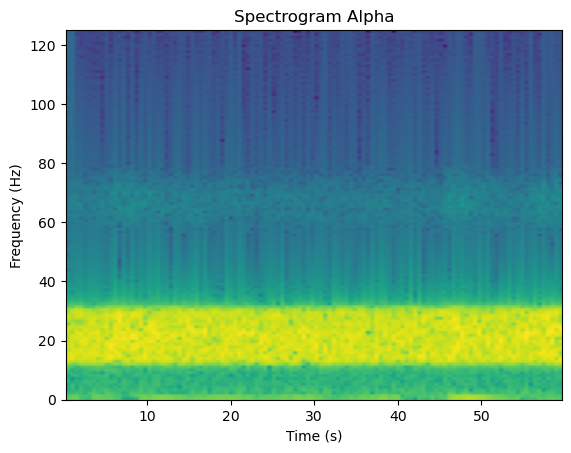

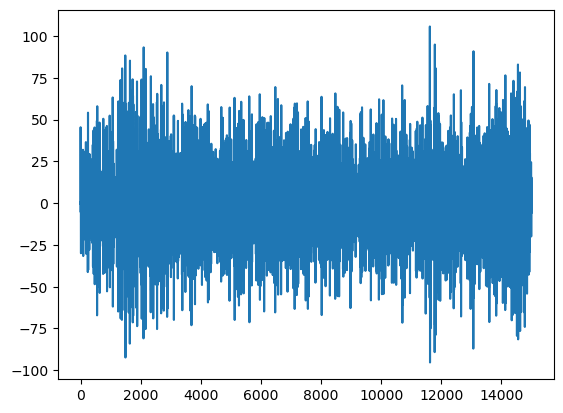

In [17]:
data = tdf.iloc[5].values.astype(float)

fig, (ax1) = plt.subplots(nrows=1, sharex=True)

plt.specgram(data.T, Fs=250, cmap="viridis")
plt.title('Spectrogram Alpha')
plt.xlabel("DATA")
plt.ylabel("TIME")
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()
plt.plot(data)

## Split

In [18]:
df = dataset['beta'].to_pandas()
df.drop(columns='__index_level_0__', inplace=True)
tdf = df.iloc[:]['Channel_Name']
_tdf = df.iloc[:, 7:]
# tdf.drop(columns='__index_level_0__', inplace=True)

In [19]:
temp = pd.concat([tdf,_tdf], axis=1)

In [20]:
_tdf.reset_index(drop=True, inplace=True)

In [21]:
temp.set_index('Channel_Name')

,Time0,Time1,Time2,Time3,Time4,Time5,Time6,Time7,Time8,Time9,...,Time14990,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999
Channel_Name,,,,,,,,,,,,,,,,,,,,,
O2-A2,7.898202825189966,142.88122843837667,236.61433897177037,262.91947708104243,218.6206413777391,123.41669862714858,11.224591966222876,-83.14246351507417,-136.37115284432664,-143.25597556607036,...,-38.18538561624355,-30.38504351660704,-10.75610552015229,12.40143078347081,29.634895270603074,34.4525564671636,25.984250405021402,9.026975453515032,-8.445742466567188,-19.070241826129752
O1-A1,-20.661551768279033,-3.3178888938537865,15.86067753030928,31.2603072389248,38.253675655680006,34.88827334475443,22.62031241163489,5.761847565643105,-10.158089773009896,-20.45395090241714,...,7.7870476180727275,-5.507603568925836,-14.78782399029838,-17.43558536768065,-13.694727988560164,-6.102808574721513,1.9258190774640624,7.619455848478791,9.773892110448452,8.762393086236592
P4-A2,-3.41998290146831,45.8839271586405,80.01636725388839,90.5881616325705,77.71478145855427,49.19564252862473,16.733360200291422,-9.061738008361983,-22.685675355176883,-25.12576258570995,...,-40.52351449687055,-35.786263357211524,-20.486154096711303,-0.8815437178080274,15.903915943673683,24.740989372333868,24.283072589617632,16.97422012578808,7.417198197417711,-0.024459182983166183
P3-A1,-8.474842975341737,29.743809470806184,57.796062224261185,68.0995833243668,59.420256820695585,36.89565307352701,9.621840505238323,-13.108130669082415,-25.303666883977183,-26.09668500116504,...,-6.858042629424794,-15.04344539915943,-16.031107492025143,-10.839016114708349,-2.9568844684676474,3.5129118801081383,5.822577047639671,3.704570918994044,-0.8231377593642435,-4.765599068662592
C4-A2,12.337216957423825,11.222600555732516,4.820974973563832,-4.428368160765661,-12.634251479343938,-16.052199463279404,-12.706753030664403,-3.3404134984312703,8.744570306585754,18.908580291239478,...,-16.62534465332586,-10.616037180733485,1.381206883417935,15.417854985005373,26.524305163087256,30.522046338567904,25.5553945635357,12.766072292052428,-4.111916403663322,-20.073534231231317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TP7-A1,2.1296883073107895,-33.5622626178618,-60.25737412134718,-71.74787167732488,-66.61392254767412,-48.04575415356499,-22.161927165417882,4.33064931243147,26.14751694713718,40.428991233546014,...,7.462059568981985,8.46826634903286,9.417394659038095,10.315181623232363,10.72578247621584,9.966556169143146,7.462854137696368,3.0801057264641116,-2.721528881186188,-8.96430995559355
CP3-A1,-13.124200069247525,-38.16569529843848,-51.958494946940306,-51.31356844947407,-38.004174542571896,-17.60071218578443,3.046220205271545,18.49336032340349,26.40145747852857,27.630980033730793,...,17.043006817245967,11.839232793691437,6.786784707736707,3.112080272133092,0.9094898245219198,-0.6074823703753225,-2.4593665852492137,-5.227480377796098,-8.696379954224014,-11.953015081912199
Cpz-A1,-18.16484472887774,-52.471322114291866,-72.14176185833188,-71.94660468893647,-53.41140196130678,-23.787135333405935,7.088143057900296,30.610174029333756,42.27872685596029,42.52052997740208,...,8.350173552691082,12.420965277003916,15.428227028622757,15.457536040785953,11.136292990435734,2.4730682794652097,-8.75972307399229,-19.38387543652064,-25.86996126486484,-25.694959939934705


In [22]:
ds = Dataset.from_pandas(temp)

In [23]:
t1 = ds.remove_columns("Channel_Name")
t1

Dataset({
    features: ['Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86', 'Time87', 'Time88', 'Time89', 'Time90', 'Time91', 'Time92', 'Time93', 'Time94', 'Time95', 'Time96', 'Time97', 'Time

In [25]:
#torch.tensor(t1, dtype=torch.float64, device='cuda')

---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
/tmp/ipykernel_7950/2034540172.py in <module>
----> 1 torch.tensor(t1, dtype=torch.float64, device='cuda')

TypeError: must be real number, not dict

## Load

In [26]:
DATASET = load_from_disk(dataset_path=DATA_DIR)

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_from_disk, Dataset
import datasets

from torch.utils.data.dataset import Dataset


class CustomDataset(Dataset):
    def __init__(self, signal: str, dataset = DATASET, normalize = None):

        super(CustomDataset, self).__init__()
        self.dataset = dataset[signal].remove_columns('__index_level_0__')
        self.dataframe = self.dataset.to_pandas()
        self.normalize = normalize
        self.tensors = self.get_tensors()


    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.tensor[idx]
    
    def shape(self):
        return self.tensor.shape
    
    def size(self) -> int:
        return super().__sizeof__(self.__len__(), *self.__getitem__(0)[0].shape)

    def get_tensors(self):
        label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
        t_label =  torch.tensor(label, dtype=torch.float)
        _time = self.dataframe.iloc[:, 7:].to_numpy().astype(float)
        t_time = torch.tensor(_time, dtype=torch.float)
        if self.normalize:
            t_time = normalize(t_time, p=1.0, dim = 0).float()   
        return TensorDataset(t_label, t_time)

train_dataset = CustomDataset('alpha', normalize=True)

In [30]:
generator_seed = set_seed(Config.seed)

train_set, val_set = random_split(train_dataset.tensors, [0.8, 0.2], generator=generator_seed)
val_set, test_set = random_split(val_set, [0.5, 0.5], generator=generator_seed)

train_dataloader = DataLoader(dataset=train_set, batch_size=Config.batch_size, shuffle=True, num_workers=20, drop_last=True, pin_memory=True, pin_memory_device="cuda",  generator=generator_seed)
val_dataloader = DataLoader(val_set, batch_size=Config.batch_size, shuffle=False, num_workers=20, drop_last=True, pin_memory=True, pin_memory_device="cuda",  generator=generator_seed)
test_dataloader = DataLoader(test_set, batch_size=Config.batch_size, shuffle=False, num_workers=20, drop_last=True, pin_memory=True, pin_memory_device="cuda",  generator=generator_seed)


In [45]:
print(train_dataset.tensors[:])

(tensor([1., 0., 1.,  ..., 0., 1., 1.]), tensor([[-1.9778e-05,  3.2310e-04,  4.4873e-04,  ...,  1.6737e-04,
          2.1833e-04,  2.5316e-04],
        [ 5.8203e-05,  1.1156e-04,  1.2298e-04,  ...,  9.3092e-05,
          9.8326e-05,  9.8273e-05],
        [-4.9336e-05,  1.1105e-04,  1.7593e-04,  ...,  2.6521e-04,
          3.0637e-04,  3.2912e-04],
        ...,
        [ 3.1560e-04,  1.8253e-04,  9.0280e-05,  ..., -2.2293e-04,
         -2.2912e-04, -2.2520e-04],
        [ 2.8597e-04,  4.2774e-04,  4.3786e-04,  ..., -1.6363e-04,
         -1.6609e-04, -1.6311e-04],
        [ 1.6880e-04,  2.9918e-04,  3.2336e-04,  ..., -5.5599e-05,
         -4.2047e-05, -3.0271e-05]]))


In [47]:
print(train_dataset.dataset.to_pandas())

          Dataset channel Channel_Name band frequency Intencity participant  \
0       Mona Lisa       0        O2-A2    3     alpha       0.1           1   
1       Mona Lisa       1        O1-A1    3     alpha       0.1           1   
2       Mona Lisa       2        P4-A2    3     alpha       0.1           1   
3       Mona Lisa       3        P3-A1    3     alpha       0.1           1   
4       Mona Lisa       4        C4-A2    3     alpha       0.1           1   
...           ...     ...          ...  ...       ...       ...         ...   
6195  Necker cube      26       TP7-A1    3     alpha         1          10   
6196  Necker cube      27       CP3-A1    3     alpha         1          10   
6197  Necker cube      28       Cpz-A1    3     alpha         1          10   
6198  Necker cube      29       CP4-A2    3     alpha         1          10   
6199  Necker cube      30       TP8-A2    3     alpha         1          10   

                    Time0                Time1     

# Model

In [31]:
import os
import random
import numpy as np
import torch.nn as nn

class RobiulModel(nn.Module):

    train_loss = []
    train_acc = []
    val_loss = []
    val_acc = []

    roc_ns_probs = []
    roc_lr_probs = []

    X_cr = []

    def __init__(self,
        in_features = Config.in_features,
        out_features = Config.out_features):
        super(RobiulModel, self).__init__()
        self.config(in_features, out_features)
        self.shap_mode = False
        self.activation = Config.activation
        self.linear_stack = nn.Sequential(
            nn.Linear(self.in_features, self.out_features, bias=False),
            self.activation,
            nn.BatchNorm1d(self.out_features),
            nn.Linear(self.out_features, 1000, bias=False),
            self.activation,
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 500, bias=False),
            self.activation,
            nn.BatchNorm1d(500),
            nn.Linear(500, 200, bias=False),
            self.activation,
            nn.BatchNorm1d(200),
            nn.Linear(200, 100, bias=False),
            self.activation,
            nn.BatchNorm1d(100),
            nn.Linear(100, 50, bias=False),
            self.activation,
            nn.BatchNorm1d(50),
            nn.Linear(50, 25, bias=False),
            self.activation,
            nn.BatchNorm1d(25),
            nn.Linear(25, 15, bias=False),
            self.activation,
            nn.BatchNorm1d(15),
            nn.Linear(15, 10, bias=False),
            self.activation,
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            # self.activation,
            # nn.BatchNorm1d(1),
            nn.Sigmoid(),
        )
        self.settings()

    def forward(self, x):
        if self.shap_mode:
            x = torch.tensor(data=x.to_numpy(), dtype=torch.float).cuda()
        logits = self.linear_stack(x)
        return logits
    
    def config(self,
               in_features = Config.in_features,
               out_features = Config.out_features):
        self.in_features = in_features
        self.out_features = out_features
    
    def settings(self):
        self = self.to(Config.device)
        self.loss_func = Config.loss_func
        self.optimizer = Adam(self.parameters(), lr=Config.lr)
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=self.optimizer,
                                                                mode='min',
                                                                patience=Config.lr_patience,
                                                                threshold=Config.threshold,
                                                                threshold_mode='rel',
                                                                cooldown=0,
                                                                min_lr=0,
                                                                eps=1e-8)

        
    def fit(self):
        EPOCHS = Config.epochs
        lr_hist = []
        best_loss = None
        threshold = 0.5 
        count = 0

        for epoch in range(EPOCHS):

            train_loop = tqdm(train_dataloader, leave=False)
            running_train_loss = []
            true_answers = 0

            model.train()
            for batch in train_loop:

                # print(f'Batch: {batch} \n batch.shape: {batch.shape} \n')
                

                X = batch[1].to(Config.device)
                targets = batch[0].squeeze().to(Config.device)

                # print(X, targets.reshape(-1, 1))

                # print(f'X: {X} \n X.shape: {X.shape}, \n y: {targets} \n y.shape: {targets.shape}')
                # break

                pred = model(X).squeeze()

                self.roc_ns_probs.append(pred)

                # threshold = 0.5  # Set your desired threshold

                predicted_classes = (pred >= threshold).to(torch.int)
                
                
                loss = self.loss_func(pred, targets.to(torch.float))
                
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                running_train_loss.append(loss)
                mean_train_loss = sum(running_train_loss) / len(running_train_loss)

                true_answers += sum(predicted_classes == targets)

                train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}] | train_loss = [{mean_train_loss:.4f}]')

            running_train_acc = true_answers / len(train_set)

            self.train_loss.append(mean_train_loss)
            self.train_acc.append(running_train_acc)

            model.eval()
            with torch.no_grad():

                running_val_loss = []
                true_answers = 0

                for batch in val_dataloader:

                    X = batch[1].to(Config.device)
                    targets = batch[0].squeeze().to(Config.device)

                    # print(f'X: {X} \n X.shape: {X.shape}, \n y: {targets} \n y.shape: {targets.shape}')
                    # break

                    pred = model(X).squeeze()
                    
                                # print(pred==targets)
                    # print(pred, targets)
                    # print(pred.shape, targets.shape)


                    loss = self.loss_func(pred, targets.to(torch.float))

                    # print(f'LOSS: {loss}')



                    predicted_classes = (pred >= threshold).to(torch.int)

                    running_val_loss.append(loss.item())
                    mean_val_loss = sum(running_val_loss) / len(running_val_loss)

                    true_answers += sum(predicted_classes == targets)
            # break
            running_val_acc = true_answers / len(val_set)

            self.val_loss.append(mean_val_loss)
            self.val_acc.append(running_val_acc)

            self.lr_scheduler.step(mean_val_loss)
            lr = self.lr_scheduler.get_last_lr()[0]
            lr_hist.append(lr)

            print(f'Epoch: [{epoch+1}/{EPOCHS}] | train_loss = [{mean_train_loss:.4f}] : train_acc = [{running_train_acc:.4f}] : val_loss = [{mean_val_loss:.4f}] : val_acc = [{running_val_acc:.4f}] : lr = [{lr}]')

            if best_loss is None:
                best_loss = mean_val_loss
            
            if best_loss > mean_val_loss:
                count = 0
                best_loss = mean_val_loss
                torch.save(model.state_dict(), f'{CP_DIR}model_stat_dict_epoch_{epoch+1}.pt')
                print(f'Find best loss=[{best_loss}], model saved on {epoch+1} epoch')

            if count >= Config.n_folds:
                print(f"\033[31m Finished on {epoch+1} epoch. \033[0m")
                break

            count += 1

    def test(self):
        test_loss = []
        test_acc = []

        model.eval()
        with torch.no_grad():

            running_test_loss = []
            true_answers = 0

            for batch in test_dataloader:

                X = batch[1].to(Config.device)
                targets = batch[0].squeeze().to(Config.device)

                # print(f'X: {X} \n X.shape: {X.shape}, \n y: {targets} \n y.shape: {targets.shape}')
                # break

                pred = model(X).squeeze()
                self.X_cr.append(pred.cpu().numpy())
                # = pd.concat(pred.cpu().numpy(), axis=0)
                

                self.roc_lr_probs.append(pred)

                
                loss = self.loss_func(pred, targets.to(torch.float))

                threshold = 0.5  # Set your desired threshold

                predicted_classes = (pred >= threshold).to(torch.int)

                running_test_loss.append(loss.item())
                mean_test_loss = sum(running_test_loss) / len(running_test_loss)

                true_answers += sum(predicted_classes == targets)

        running_test_acc = true_answers / len(test_set)

        test_loss.append(mean_test_loss)
        test_acc.append(running_test_acc)

        print(f'test_loss: [{mean_test_loss:.4f}] : test_acc: [{running_test_acc:.4f}]')

model = RobiulModel()
model.shap_mode = False

In [32]:
from torch.optim import Adam, AdamW

model.optimizer = AdamW(model.parameters(), lr=Config.lr)
model.fit()

Epoch: [1/200] | train_loss = [129.7450] : train_acc = [0.5377] : val_loss = [127.6130] : val_acc = [0.5210] : lr = [0.01]


Epoch: [2/200] | train_loss = [126.6471] : train_acc = [0.6790] : val_loss = [123.5779] : val_acc = [0.6758] : lr = [0.01]
Find best loss=[123.57787238226996], model saved on 2 epoch


Epoch: [3/200] | train_loss = [124.5827] : train_acc = [0.7534] : val_loss = [122.1317] : val_acc = [0.7371] : lr = [0.01]
Find best loss=[122.13166385226779], model saved on 3 epoch


Epoch: [4/200] | train_loss = [122.7125] : train_acc = [0.8222] : val_loss = [122.8034] : val_acc = [0.7161] : lr = [0.01]


Epoch: [5/200] | train_loss = [122.9825] : train_acc = [0.8163] : val_loss = [122.2639] : val_acc = [0.7419] : lr = [0.01]


Epoch: [6/200] | train_loss = [122.5128] : train_acc = [0.8329] : val_loss = [121.9829] : val_acc = [0.7484] : lr = [0.01]
Find best loss=[121.98292117648654], model saved on 6 epoch


Epoch: [7/200] | train_loss = [122.3064] : train_acc = [0.8442] : val_loss = [121.0545] : val_acc = [0.7758] : lr = [0.01]
Find best loss=[121.05447218153212], model saved on 7 epoch


Epoch: [8/200] | train_loss = [122.0574] : train_acc = [0.8466] : val_loss = [120.8420] : val_acc = [0.7565] : lr = [0.01]
Find best loss=[120.84200202094183], model saved on 8 epoch


Epoch: [9/200] | train_loss = [122.2683] : train_acc = [0.8446] : val_loss = [121.9282] : val_acc = [0.7306] : lr = [0.01]


Epoch: [10/200] | train_loss = [121.2268] : train_acc = [0.8661] : val_loss = [120.3560] : val_acc = [0.7968] : lr = [0.01]
Find best loss=[120.35604010687933], model saved on 10 epoch


Epoch: [11/200] | train_loss = [120.8170] : train_acc = [0.8873] : val_loss = [120.7659] : val_acc = [0.7694] : lr = [0.01]


Epoch: [12/200] | train_loss = [120.8108] : train_acc = [0.8847] : val_loss = [121.6583] : val_acc = [0.7548] : lr = [0.01]


Epoch: [13/200] | train_loss = [121.4064] : train_acc = [0.8768] : val_loss = [120.6819] : val_acc = [0.7839] : lr = [0.01]


Epoch: [14/200] | train_loss = [121.6851] : train_acc = [0.8679] : val_loss = [122.2712] : val_acc = [0.7403] : lr = [0.01]


Epoch: [15/200] | train_loss = [122.6351] : train_acc = [0.8290] : val_loss = [121.5071] : val_acc = [0.7597] : lr = [0.01]


Epoch: [16/200] | train_loss = [122.2089] : train_acc = [0.8440] : val_loss = [120.6274] : val_acc = [0.7855] : lr = [0.001]


Epoch: [17/200] | train_loss = [121.5587] : train_acc = [0.8601] : val_loss = [121.3081] : val_acc = [0.7677] : lr = [0.001]


Epoch: [18/200] | train_loss = [120.9475] : train_acc = [0.8823] : val_loss = [123.0008] : val_acc = [0.7226] : lr = [0.001]


Epoch: [19/200] | train_loss = [121.8966] : train_acc = [0.8565] : val_loss = [120.8301] : val_acc = [0.7500] : lr = [0.001]


Epoch: [20/200] | train_loss = [121.1124] : train_acc = [0.8728] : val_loss = [120.2430] : val_acc = [0.7984] : lr = [0.001]
Find best loss=[120.24303181966145], model saved on 20 epoch


Epoch: [21/200] | train_loss = [120.7790] : train_acc = [0.8923] : val_loss = [119.0676] : val_acc = [0.8323] : lr = [0.001]
Find best loss=[119.06764051649306], model saved on 21 epoch


Epoch: [22/200] | train_loss = [121.4850] : train_acc = [0.8758] : val_loss = [120.3324] : val_acc = [0.7919] : lr = [0.001]


Epoch: [23/200] | train_loss = [120.8691] : train_acc = [0.8905] : val_loss = [119.6112] : val_acc = [0.8129] : lr = [0.001]


Epoch: [24/200] | train_loss = [121.2608] : train_acc = [0.8774] : val_loss = [120.7453] : val_acc = [0.7855] : lr = [0.001]


Epoch: [25/200] | train_loss = [122.0985] : train_acc = [0.8494] : val_loss = [121.6158] : val_acc = [0.7516] : lr = [0.001]


Epoch: [26/200] | train_loss = [121.3756] : train_acc = [0.8700] : val_loss = [120.9448] : val_acc = [0.7839] : lr = [0.001]


Epoch: [27/200] | train_loss = [121.1131] : train_acc = [0.8843] : val_loss = [120.0924] : val_acc = [0.8032] : lr = [0.0001]


Epoch: [28/200] | train_loss = [120.6183] : train_acc = [0.9062] : val_loss = [119.4984] : val_acc = [0.8290] : lr = [0.0001]


Epoch: [29/200] | train_loss = [120.1998] : train_acc = [0.9056] : val_loss = [119.9083] : val_acc = [0.8081] : lr = [0.0001]


Epoch: [30/200] | train_loss = [120.8932] : train_acc = [0.8873] : val_loss = [120.0726] : val_acc = [0.8032] : lr = [0.0001]


Epoch: [31/200] | train_loss = [120.2475] : train_acc = [0.9115] : val_loss = [119.5497] : val_acc = [0.8177] : lr = [0.0001]


Epoch: [32/200] | train_loss = [120.1395] : train_acc = [0.9119] : val_loss = [119.8809] : val_acc = [0.8048] : lr = [0.0001]


Epoch: [33/200] | train_loss = [120.0885] : train_acc = [0.9081] : val_loss = [120.2480] : val_acc = [0.7903] : lr = [1e-05]


Epoch: [34/200] | train_loss = [120.4038] : train_acc = [0.9040] : val_loss = [119.2219] : val_acc = [0.8306] : lr = [1e-05]


Epoch: [35/200] | train_loss = [120.4911] : train_acc = [0.9006] : val_loss = [119.3250] : val_acc = [0.8306] : lr = [1e-05]


Epoch: [36/200] | train_loss = [119.7895] : train_acc = [0.9244] : val_loss = [118.8601] : val_acc = [0.8387] : lr = [1e-05]
Find best loss=[118.86011759440105], model saved on 36 epoch


Epoch: [37/200] | train_loss = [120.6116] : train_acc = [0.8917] : val_loss = [121.1387] : val_acc = [0.7629] : lr = [1e-05]


Epoch: [38/200] | train_loss = [122.5825] : train_acc = [0.8329] : val_loss = [121.9353] : val_acc = [0.7484] : lr = [1e-05]


Epoch: [39/200] | train_loss = [122.1296] : train_acc = [0.8421] : val_loss = [122.4467] : val_acc = [0.7387] : lr = [1e-05]


Epoch: [40/200] | train_loss = [122.5340] : train_acc = [0.8458] : val_loss = [122.0292] : val_acc = [0.7468] : lr = [1e-05]


Epoch: [41/200] | train_loss = [121.5788] : train_acc = [0.8645] : val_loss = [121.4603] : val_acc = [0.7613] : lr = [1e-05]


Epoch: [42/200] | train_loss = [121.4448] : train_acc = [0.8681] : val_loss = [121.6070] : val_acc = [0.7484] : lr = [1.0000000000000002e-06]


Epoch: [43/200] | train_loss = [121.8337] : train_acc = [0.8585] : val_loss = [121.2020] : val_acc = [0.7710] : lr = [1.0000000000000002e-06]


Epoch: [44/200] | train_loss = [121.0411] : train_acc = [0.8738] : val_loss = [120.8641] : val_acc = [0.7839] : lr = [1.0000000000000002e-06]


Epoch: [45/200] | train_loss = [120.5134] : train_acc = [0.9002] : val_loss = [119.4994] : val_acc = [0.8226] : lr = [1.0000000000000002e-06]


Epoch: [46/200] | train_loss = [119.6997] : train_acc = [0.9208] : val_loss = [118.8099] : val_acc = [0.8435] : lr = [1.0000000000000002e-06]
Find best loss=[118.80985090467665], model saved on 46 epoch


Epoch: [47/200] | train_loss = [120.1386] : train_acc = [0.9065] : val_loss = [121.2097] : val_acc = [0.7597] : lr = [1.0000000000000002e-06]


Epoch: [48/200] | train_loss = [120.4952] : train_acc = [0.9046] : val_loss = [118.8647] : val_acc = [0.8468] : lr = [1.0000000000000002e-07]


Epoch: [49/200] | train_loss = [119.7270] : train_acc = [0.9218] : val_loss = [119.0331] : val_acc = [0.8355] : lr = [1.0000000000000002e-07]


Epoch: [50/200] | train_loss = [119.9522] : train_acc = [0.9187] : val_loss = [119.5079] : val_acc = [0.8145] : lr = [1.0000000000000002e-07]


Epoch: [51/200] | train_loss = [121.1023] : train_acc = [0.8837] : val_loss = [119.4610] : val_acc = [0.8210] : lr = [1.0000000000000002e-07]


Epoch: [52/200] | train_loss = [121.3149] : train_acc = [0.8802] : val_loss = [120.3144] : val_acc = [0.7839] : lr = [1.0000000000000002e-07]


Epoch: [53/200] | train_loss = [120.4433] : train_acc = [0.8980] : val_loss = [118.9296] : val_acc = [0.8371] : lr = [1.0000000000000002e-07]


Epoch: [54/200] | train_loss = [120.4108] : train_acc = [0.8980] : val_loss = [120.1406] : val_acc = [0.8032] : lr = [1.0000000000000004e-08]


Epoch: [55/200] | train_loss = [120.6582] : train_acc = [0.8909] : val_loss = [119.3850] : val_acc = [0.8258] : lr = [1.0000000000000004e-08]


Epoch: [56/200] | train_loss = [120.2774] : train_acc = [0.9107] : val_loss = [118.9091] : val_acc = [0.8355] : lr = [1.0000000000000004e-08]


Epoch: [57/200] | train_loss = [120.2068] : train_acc = [0.9097] : val_loss = [119.6638] : val_acc = [0.8048] : lr = [1.0000000000000004e-08]


Epoch: [58/200] | train_loss = [120.0584] : train_acc = [0.9065] : val_loss = [118.5179] : val_acc = [0.8548] : lr = [1.0000000000000004e-08]
Find best loss=[118.51790788438585], model saved on 58 epoch


Epoch: [59/200] | train_loss = [119.7477] : train_acc = [0.9254] : val_loss = [118.2594] : val_acc = [0.8532] : lr = [1.0000000000000004e-08]
Find best loss=[118.25944264729817], model saved on 59 epoch


Epoch: [60/200] | train_loss = [119.7861] : train_acc = [0.9234] : val_loss = [117.9921] : val_acc = [0.8661] : lr = [1.0000000000000004e-08]
Find best loss=[117.99208577473958], model saved on 60 epoch


Epoch: [61/200] | train_loss = [120.1370] : train_acc = [0.9075] : val_loss = [120.8741] : val_acc = [0.7581] : lr = [1.0000000000000004e-08]


Epoch: [62/200] | train_loss = [119.8751] : train_acc = [0.9202] : val_loss = [117.9910] : val_acc = [0.8629] : lr = [1.0000000000000004e-08]
Find best loss=[117.99098714192708], model saved on 62 epoch


Epoch: [63/200] | train_loss = [120.3390] : train_acc = [0.9002] : val_loss = [120.5195] : val_acc = [0.7855] : lr = [1.0000000000000004e-08]


Epoch: [64/200] | train_loss = [121.2239] : train_acc = [0.8710] : val_loss = [121.3754] : val_acc = [0.7710] : lr = [1.0000000000000004e-08]


Epoch: [65/200] | train_loss = [122.1331] : train_acc = [0.8562] : val_loss = [123.2154] : val_acc = [0.7113] : lr = [1.0000000000000004e-08]


Epoch: [66/200] | train_loss = [123.6721] : train_acc = [0.8079] : val_loss = [123.2505] : val_acc = [0.7145] : lr = [1.0000000000000004e-08]


Epoch: [67/200] | train_loss = [123.0502] : train_acc = [0.8139] : val_loss = [122.8855] : val_acc = [0.7000] : lr = [1.0000000000000004e-08]


Epoch: [68/200] | train_loss = [121.6161] : train_acc = [0.8540] : val_loss = [120.3877] : val_acc = [0.7919] : lr = [1.0000000000000004e-08]


Epoch: [69/200] | train_loss = [120.7503] : train_acc = [0.8946] : val_loss = [120.2006] : val_acc = [0.7935] : lr = [1.0000000000000004e-08]


Epoch: [70/200] | train_loss = [120.8109] : train_acc = [0.8998] : val_loss = [119.6895] : val_acc = [0.8129] : lr = [1.0000000000000004e-08]


Epoch: [71/200] | train_loss = [120.5555] : train_acc = [0.8998] : val_loss = [121.9393] : val_acc = [0.7500] : lr = [1.0000000000000004e-08]


Epoch: [72/200] | train_loss = [121.2034] : train_acc = [0.8798] : val_loss = [120.8158] : val_acc = [0.7871] : lr = [1.0000000000000004e-08]


Epoch: [73/200] | train_loss = [120.7684] : train_acc = [0.8859] : val_loss = [121.2892] : val_acc = [0.7710] : lr = [1.0000000000000004e-08]


Epoch: [74/200] | train_loss = [120.8897] : train_acc = [0.8800] : val_loss = [120.1870] : val_acc = [0.8016] : lr = [1.0000000000000004e-08]


Epoch: [75/200] | train_loss = [121.8076] : train_acc = [0.8631] : val_loss = [120.0287] : val_acc = [0.8065] : lr = [1.0000000000000004e-08]


Epoch: [76/200] | train_loss = [121.1788] : train_acc = [0.8843] : val_loss = [120.2785] : val_acc = [0.8065] : lr = [1.0000000000000004e-08]


Epoch: [77/200] | train_loss = [121.2630] : train_acc = [0.8861] : val_loss = [120.2283] : val_acc = [0.8048] : lr = [1.0000000000000004e-08]


Epoch: [78/200] | train_loss = [122.5658] : train_acc = [0.8466] : val_loss = [120.9828] : val_acc = [0.7774] : lr = [1.0000000000000004e-08]


Epoch: [79/200] | train_loss = [122.1507] : train_acc = [0.8472] : val_loss = [120.1002] : val_acc = [0.8000] : lr = [1.0000000000000004e-08]


Epoch: [80/200] | train_loss = [120.4966] : train_acc = [0.8931] : val_loss = [118.7675] : val_acc = [0.8419] : lr = [1.0000000000000004e-08]


Epoch: [81/200] | train_loss = [120.0276] : train_acc = [0.9151] : val_loss = [118.8413] : val_acc = [0.8452] : lr = [1.0000000000000004e-08]


Epoch: [82/200] | train_loss = [119.7926] : train_acc = [0.9198] : val_loss = [118.8769] : val_acc = [0.8403] : lr = [1.0000000000000004e-08]
 Finished on 82 epoch. 


In [33]:
model.test()

test_loss: [110.3229] : test_acc: [0.8581]


# Metrics

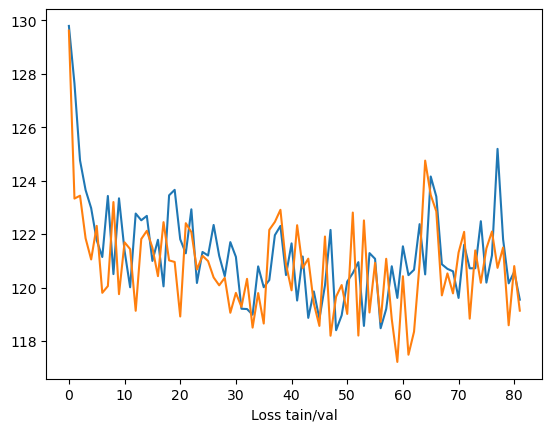

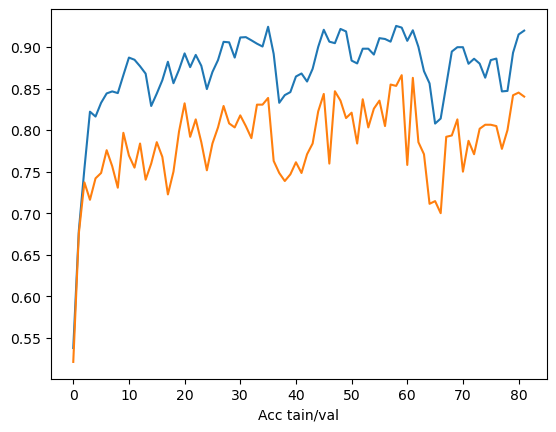

In [34]:
plt.plot(torch.normal(tensor(model.train_loss)).to("cpu"))
plt.plot(torch.normal(tensor(model.val_loss)).to("cpu"))
plt.xlabel('Loss tain/val')

plt.show()

plt.plot(torch.asarray(model.train_acc).to("cpu"))
plt.plot(torch.asarray(model.val_acc).to("cpu"))
plt.xlabel('Acc tain/val')
plt.show()

## ROC curve

No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.941


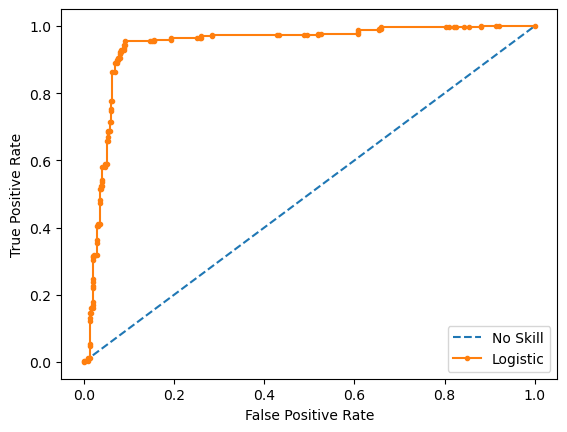

In [35]:
lr_probs = np.hstack([tensor.detach().cpu().numpy() for tensor in model.roc_lr_probs])
testy = test_set[:][0][:len(lr_probs)]

# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(testy))]

# calculate scores
ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)


ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)

# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)
# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

## Shap

In [59]:
shap.initjs()

In [60]:
df = DATASET['delta'].to_pandas()
df

,Dataset,channel,Channel_Name,band,frequency,Intencity,participant,Time0,Time1,Time2,...,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999,__index_level_0__
0,Mona Lisa,0,O2-A2,1,delta,0.1,1,7.772970544879844,30.677260160175926,53.41413103932174,...,22.885068815607795,22.34066999595244,21.82352034357666,21.333030537649503,20.86100440490908,20.41249461889208,19.997011777502465,19.6112798564008,19.253296357169667,0
1,Mona Lisa,1,O1-A1,1,delta,0.1,1,3.5522059078923567,6.295904135536704,9.036222397464512,...,19.588754952288987,18.119286213923715,16.61815966164349,15.088949880952768,13.542232213787255,11.998175358860179,10.470979635699344,8.958667902212145,7.460397960314374,1
2,Mona Lisa,2,P4-A2,1,delta,0.1,1,15.108176599269667,25.54891796871998,35.96358649636977,...,-4.679370408629602,-4.529878757525804,-4.25758485064557,-3.867217313307317,-3.3644148923882247,-2.7542051780022607,-2.040050773983246,-1.2267393965792945,-0.3193421504075806,2
3,Mona Lisa,3,P3-A1,1,delta,0.1,1,29.873366329465867,38.39422888844447,46.917213057741165,...,-0.3621678784078668,-0.4997429014105872,-0.548831119445365,-0.5132411735242943,-0.38905979926704237,-0.16728967693891628,0.1513494520793921,0.5580716770116986,1.0519768799376996,3
4,Mona Lisa,4,C4-A2,1,delta,0.1,1,8.9500413838161,12.746145708344514,16.674943619058503,...,23.928307291732757,24.552676931875244,25.20547623191569,25.884569191047152,26.589298350887965,27.31903654537524,28.07596027012317,28.86312436087364,29.68184437745307,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6195,Necker cube,26,TP7-A1,1,delta,1,10,-1.027511266877348,-8.418481446589299,-15.80441466535556,...,-29.212248078178625,-30.00080404120558,-30.736847620452856,-31.41236189932247,-32.02399716377283,-32.57375454226612,-33.06097067692424,-33.48307954704039,-33.842645708693524,18595
6196,Necker cube,27,CP3-A1,1,delta,1,10,2.5118338166869565,-5.284314072298276,-13.125600337603425,...,-55.700581721078976,-55.674397736065245,-55.58038443575897,-55.40934022858181,-55.15821282992474,-54.827146093667466,-54.414632530576924,-53.91904605527582,-53.34375139088061,18596
6197,Necker cube,28,Cpz-A1,1,delta,1,10,2.662754530873961,-6.601947214361611,-15.913873341756092,...,-46.33551769249509,-46.56335387152752,-46.761456915680796,-46.91117049915582,-47.00212144408083,-47.02838215750539,-46.98008384222557,-46.846249827056944,-46.62313658327007,18597
6198,Necker cube,29,CP4-A2,1,delta,1,10,12.902088929394177,23.401282715378837,33.79406355106747,...,-31.2456379678617,-30.122226797622368,-29.011567470065117,-27.906778569944336,-26.815459444292124,-25.74751187451037,-24.703500976892357,-23.68195443888358,-22.68399739019216,18598


In [61]:
y = df['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
y

0       1
1       0
2       1
3       0
4       1
       ..
6195    0
6196    0
6197    0
6198    1
6199    1
Name: Channel_Name, Length: 6200, dtype: int8

In [62]:
X = DATASET['delta'].to_pandas()

In [63]:
X = X.iloc[:,7:]
X.drop('__index_level_0__', axis=1, inplace=True)

In [64]:
print(type(X), X)

<class 'pandas.core.frame.DataFrame'>                    Time0               Time1                Time2  \
0      7.772970544879844  30.677260160175926    53.41413103932174   
1     3.5522059078923567   6.295904135536704    9.036222397464512   
2     15.108176599269667   25.54891796871998    35.96358649636977   
3     29.873366329465867   38.39422888844447   46.917213057741165   
4        8.9500413838161  12.746145708344514   16.674943619058503   
...                  ...                 ...                  ...   
6195  -1.027511266877348  -8.418481446589299   -15.80441466535556   
6196  2.5118338166869565  -5.284314072298276  -13.125600337603425   
6197   2.662754530873961  -6.601947214361611  -15.913873341756092   
6198  12.902088929394177  23.401282715378837    33.79406355106747   
6199   7.653620406772357  13.750373713790397    19.76020602669619   

                    Time3                Time4                Time5  \
0       75.88141010001931    97.97543362369184   119.594661808

In [65]:
generator_seed = set_seed(Config.seed)

samples = X.iloc[np.random.choice(np.arange(len(X)), 10, replace=False)]
samples = samples.iloc[:, :30]
# t_samples = torch.tensor(samples.to_numpy(), dtype=torch.float32)
print(samples, '\n', samples.shape)

                    Time0                Time1                Time2  \
5367   19.319482575183038   25.936682247417718    32.63722668803936   
2463  -27.087249019588132   -25.28599272432344  -23.404496426899865   
2505  -10.628305083125218  -1.3818791235879575    7.873609506098306   
5417     9.76263242440297   10.164107342611851   10.612548838236771   
1315   19.278829656122223   28.887130909139323    38.37866958372327   
296     21.82308503193318   20.030293923818327   18.192263360867138   
969     13.37344045940606   18.440618168536716    23.41630274976457   
4881    25.19973546379911    28.26738690790803    31.30218514672967   
683      7.62844884240247   -2.564942727948165  -12.687949620832038   
3133   -7.354031437603905  -2.3827575708669535   2.5266143829447825   

                    Time3               Time4                Time5  \
5367    39.37465467704995   46.09830670609441    52.75566014577563   
2463  -21.452541216641777  -19.43877377542596  -17.369460793742764   
2505   1

In [66]:
model = RobiulModel(samples.shape[1], 2500)
model.shap_mode = True
model

RobiulModel(
  (activation): ReLU()
  (linear_stack): Sequential(
    (0): Linear(in_features=30, out_features=2500, bias=False)
    (1): ReLU()
    (2): BatchNorm1d(2500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=2500, out_features=1000, bias=False)
    (4): ReLU()
    (5): BatchNorm1d(1000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=1000, out_features=500, bias=False)
    (7): ReLU()
    (8): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=500, out_features=200, bias=False)
    (10): ReLU()
    (11): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=200, out_features=100, bias=False)
    (13): ReLU()
    (14): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Linear(in_features=100, out_features=50, bias=False)
    (16): ReLU()

In [81]:
samples=samples.astype(float)

In [82]:
samples.dtypes

Time0     float64
Time1     float64
Time2     float64
Time3     float64
Time4     float64
Time5     float64
Time6     float64
Time7     float64
Time8     float64
Time9     float64
Time10    float64
Time11    float64
Time12    float64
Time13    float64
Time14    float64
Time15    float64
Time16    float64
Time17    float64
Time18    float64
Time19    float64
Time20    float64
Time21    float64
Time22    float64
Time23    float64
Time24    float64
Time25    float64
Time26    float64
Time27    float64
Time28    float64
Time29    float64
dtype: object

In [83]:
explainer = shap.Explainer(model, samples, max_evals = 30001)
# print(explainer)
shap_values = explainer(samples)
# print(shap_values)

# visualize the first prediction's explanation
# shap.plots.waterfall(shap_values[0])

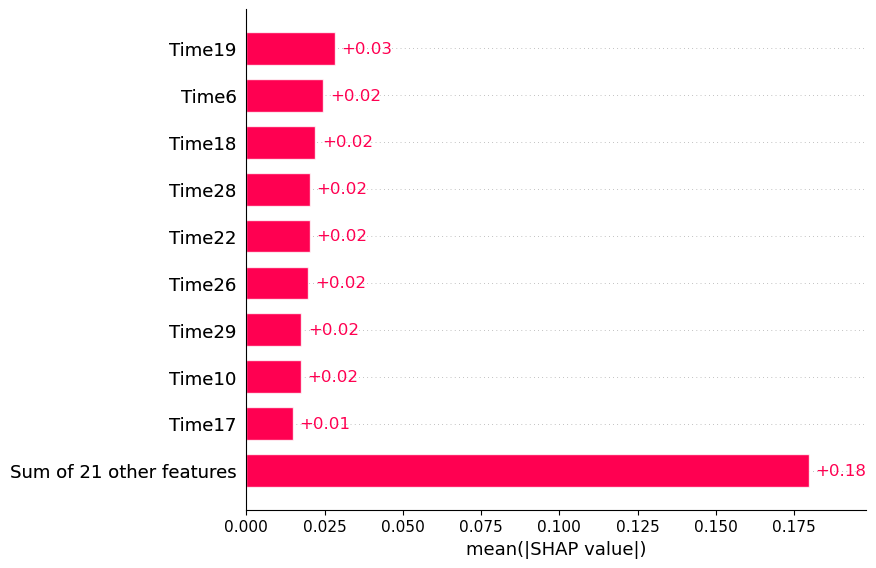

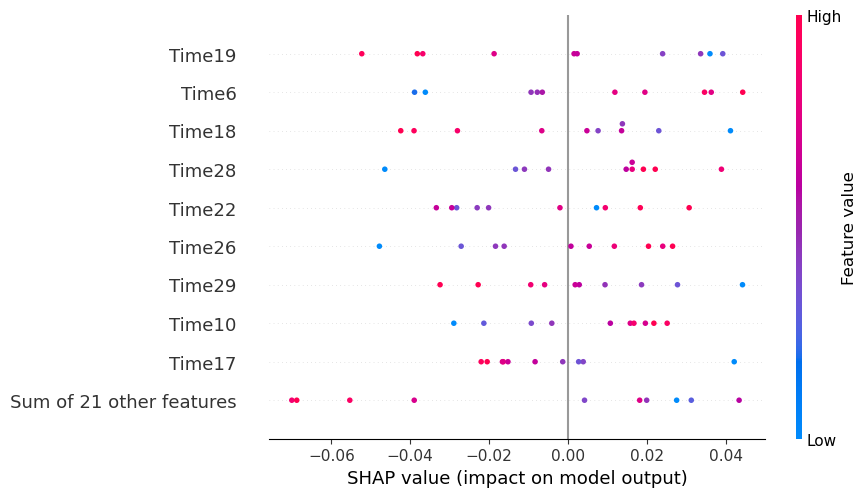

In [84]:
shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)


## Classification report

In [55]:
y_test_pred = np.array(model.X_cr).flatten().tolist()
y_test_pred = list(map(lambda x: round(x), y_test_pred))
y_test = test_set[:len(y_test_pred)][0]

classificationReport = classification_report(y_test, y_test_pred)
print(classificationReport)

              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93       316
         1.0       0.89      0.94      0.92       260

    accuracy                           0.92       576
   macro avg       0.92      0.93      0.92       576
weighted avg       0.92      0.92      0.92       576



In [56]:
!pip install tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 2.6 MB/s eta 0:00:00 MB/s eta 0:00:01:01


In [58]:
!pip install shap